<a href="https://colab.research.google.com/github/whateveri/models/blob/simple_cGAN/simple_GAN_Pix2Pix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

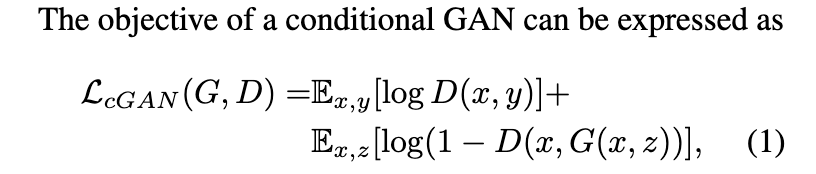

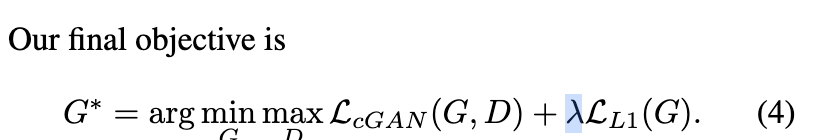

In [1]:
import torch
from torchvision import transforms,utils
import os
import random
import torch.nn as nn
from torch.nn import init
import torch.optim as optim
from torch.utils.data import DataLoader,Dataset
from PIL import Image
from pathlib import Path

device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
#download satellite map database
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alincijov/pix2pix-maps")

print("Path to dataset files:", path)

100%|██████████| 239M/239M [00:07<00:00, 34.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alincijov/pix2pix-maps/versions/1


In [3]:
if os.path.exists(os.path.join(path,"train")):
    print("path exist")
else:
    print("not exist")

path exist


In [4]:
#Config
img_size=256
data_root=os.path.join(path,"train")
out_dir=os.getcwd()
batch_size=8
lr=2e-6
beta=0.5 #for Adam Optim
lambda_L1=100.0 #for update the G
epoch_num=200
save_frequency=5 #save sample and checkpoints every 5 epoches


In [22]:
#process dataset

class PairedDataset(Dataset):
    def __init__(self,data_root,image_size=img_size,is_Train=True) :
        self.root=Path(data_root)
        self.files=sorted([p for p in self.root.glob("*") if p.suffix.lower() in (".png" ,".jpg",".jpeg") ])
        self.transform=transforms.Compose([
            transforms.Resize((image_size,image_size*2)) if True else transforms.Lambda(lambda x:x),
            transforms.Lambda(lambda img: img.convert("RGB")),
            transforms.ToTensor(),
            transforms.Normalize((0.5,)*3,(0.5,)*3)  #[-1,1]
        ])
        self.image_size=image_size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        p=self.files[index]
        img=Image.open(p)
        w,h=img.size
        #resize
        img=img.resize((self.image_size*2,self.image_size),Image.Resampling.BICUBIC)
        img=img.convert("RGB")
        t=transforms.ToTensor()(img)
        c,H,W=t.shape
        left=t[:,:,:W//2]
        right=t[:,:,W//2:]
        return left,right






In [ ]:
#for the dataset have two files with corresponding images as input and target
class PairedfilesDataset(Dataset):
    def __init__(self,input_dir,target_dir,image_size) :
        self.input_dir=input_dir
        self.target_dir=target_dir
        self.image_size=image_size
        self.input_files=sorted([p for p in self.input_dir.glob("*") if p.suffix.lower() in (".png" ,".jpg",".jpeg") ])

        self.target_files=sorted([p for p in self.target_dir.glob("*") if p.suffix.lower() in (".png" ,".jpg",".jpeg") ])

        self.transform=transforms.Compose([
            transforms.Resize((image_size,image_size)) ,
            transforms.ToTensor(),
            transforms.Normalize((0.5,)*3,(0.5,)*3)  #[-1,1]
        ])

    def __len__(self):
        return len(self.input_files)

    def __getitem__(self,idx):
        input_img=Image.open(self.input_files[idx]).convert('RGB')
        target_img=Image.open(self.target_files[idx]).convert('RGB')
        input_img=self.transform(input_img)
        target_img=self.transform(target_img)
        return input_img, target_img




In [23]:
dataset=PairedDataset(data_root=data_root,image_size=img_size)
loader=DataLoader(dataset=dataset,batch_size=batch_size,shuffle=True,num_workers=4,pin_memory=True)
print(len(loader))

137


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [25]:
print(f"loader shape:{next(iter(loader))[1].shape}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


loader shape:torch.Size([8, 3, 256, 256])


In [33]:
inp,tgt = next(iter(loader))
print(f'inp:{inp.shape}, tgt:{tgt.shape}')

inp:torch.Size([8, 3, 256, 256]), tgt:torch.Size([8, 3, 256, 256])


# Generator (U-Net)

In [7]:
#conv block

def conv_block(in_channels,out_channels,kernel_size=4,stride=2,padding=1,norm=True,activation=True):
    layers=[nn.Conv2d(in_channels=in_channels,
                      out_channels=out_channels,
                      kernel_size=kernel_size,
                      stride=stride,
                      padding=padding,
                      bias=not norm)]

    if norm:
        layers.append(nn.BatchNorm2d(num_features=out_channels))
    if activation:
        layers.append(nn.LeakyReLU(negative_slope=0.2,inplace=True))

    return nn.Sequential(*layers)



In [13]:
#deconv block

def deconv_block(in_channels,out_channels,kernel_size=4,stride=2,padding=1,norm=True,dropout=False):
    layers=[nn.ConvTranspose2d(in_channels=in_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding,
                               bias= not norm)]
    if norm:
        layers.append(nn.BatchNorm2d(num_features=out_channels))
    if dropout:
        layers.append(nn.Dropout2d(p=0.5))

    layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)



In [27]:
class UnetGenerator(nn.Module):
    def __init__(self, in_channels=3,out_channels=3,hidden=64) :
        super().__init__()
        #encoder
        self.enc1=nn.Sequential(nn.Conv2d(in_channels=in_channels,
                                          out_channels=hidden,
                                          kernel_size=4,
                                          stride=2,
                                          padding=1),
                                nn.LeakyReLU(0.2,True)) #first one no BatchNorm
        self.conv2=conv_block(in_channels=hidden,
                              out_channels=hidden*2)

        self.conv3=conv_block(in_channels=hidden*2,
                              out_channels=hidden*4)

        self.conv4=conv_block(in_channels=hidden*4,
                              out_channels=hidden*8)

        self.conv5=conv_block(in_channels=hidden*8,
                              out_channels=hidden*8)

        self.conv6=conv_block(in_channels=hidden*8,
                              out_channels=hidden*8)

        self.conv7=conv_block(in_channels=hidden*8,
                              out_channels=hidden*8)

        self.conv8=conv_block(in_channels=hidden*8,
                              out_channels=hidden*8,
                              norm=False,activation=False) #bottleneck

        #decode+linking layers
        self.decon1=deconv_block(in_channels=hidden*8,
                                 out_channels=hidden*8,
                                 dropout=True)
        self.decon2=deconv_block(in_channels=hidden*8+hidden*8,
                                 out_channels=hidden*8,
                                 dropout=True)
        self.decon3=deconv_block(in_channels=hidden*8+hidden*8,
                                 out_channels=hidden*8,
                                 dropout=True)
        self.decon4=deconv_block(in_channels=hidden*8+hidden*8,
                                 out_channels=hidden*8)

        self.decon5=deconv_block(in_channels=hidden*8+hidden*8,
                                 out_channels=hidden*4)

        self.decon6=deconv_block(in_channels=hidden*4+hidden*4,
                                 out_channels=hidden*2)

        self.decon7=deconv_block(in_channels=hidden*2+hidden*2,
                                 out_channels=hidden)

        self.decon8=nn.Sequential(
            nn.ConvTranspose2d(in_channels=hidden+hidden,
                               out_channels=out_channels,
                               kernel_size=4,
                               stride=2,
                               padding=1),
            nn.Tanh() #output in [-1,1]
        )

    def forward(self,x):
        e1=self.enc1(x)

        e2=self.conv2(e1)
        e3=self.conv3(e2)
        e4=self.conv4(e3)
        e5=self.conv5(e4)
        e6=self.conv6(e5)
        e7=self.conv7(e6)
        e8=self.conv8(e7)

        d1=self.decon1(e8)

        d2_in=torch.cat([d1,e7],dim=1)

        d2=self.decon2(d2_in)

        d3_in=torch.cat([d2,e6],dim=1)

        d3=self.decon3(d3_in)

        d4_in=torch.cat([d3,e5],dim=1)

        d4=self.decon4(d4_in)

        d5_in=torch.cat([d4,e4],dim=1)

        d5=self.decon5(d5_in)

        d6_in=torch.cat([d5,e3],dim=1)

        d6=self.decon6(d6_in)

        d7_in=torch.cat([d6,e2],dim=1)

        d7=self.decon7(d7_in)

        d8_in=torch.cat([d7,e1],dim=1)

        d8=self.decon8(d8_in)

        return d8




# Discriminator (PatchGAN)

In [15]:
class NLayerDiscriminator(nn.Module):
    def __init__(self, in_channels=6,hidden=64) :                            #input is concatenated(input,target) channel=3+3=6
        super().__init__()
        self.layer1=nn.Sequential(
            nn.Conv2d(in_channels=in_channels,
                      out_channels=hidden,
                      kernel_size=4,
                      stride=2,
                      padding=1),
            nn.LeakyReLU(0.2,True)
        )

        self.layer2=conv_block(in_channels=hidden,
                               out_channels=hidden*2
                               )

        self.layer3=conv_block(in_channels=hidden*2,
                               out_channels=hidden*4)

        self.layer4=conv_block(in_channels=hidden*4,
                               out_channels=hidden*8,
                               stride=1)

        self.last=nn.Conv2d(in_channels=hidden*8,
                            out_channels=1,
                            kernel_size=4,
                            stride=1,
                            padding=1) #output 1 channel prediction map

    def forward(self,input,target):
        x=torch.cat([input,target],dim=1) #x:[B,3+3,256,256]
        x=self.layer1(x) #[B,C,128,128]
        x=self.layer2(x) #[B,C,64,64]
        x=self.layer3(x) #[B,C,32,32]
        x=self.layer4(x) #[B,C,31,31]
        x=self.last(x) #[B,C,30,30]
        return x


# Utililies

In [11]:
#define initialization function for weight

def init_weights(m,scaling_factor=0.02): #use "normal" initialization method, in which scaling factor=0.02
    classname=m.__class__.__name__

    if isinstance(m,(nn.Conv2d,nn.ConvTranspose2d)):
        init.normal_(m.weight.data, 0.0, scaling_factor)
        if m.bias is not None:
            init.constant_(m.bias.data, 0.0)
    elif isinstance(m,nn.BatchNorm2d):
        init.normal_(m.weight.data, 1.0, scaling_factor)
        init.constant_(m.bias.data, 0.0)

#save samples
def save_samples(input_batch,target_batch,gen_batch,epoch,out_dir):
    #denormalize from [-1,1] to [0,1]
    def denorm(t):
        return (t+1.0) / 2.0
    grid=utils.make_grid(torch.cat([input_batch,target_batch,gen_batch],dim=0))
    grid=denorm(grid)
    utils.save_image(grid,os.path.join(out_dir,f"sample_epoch_{epoch:04d}.png"))


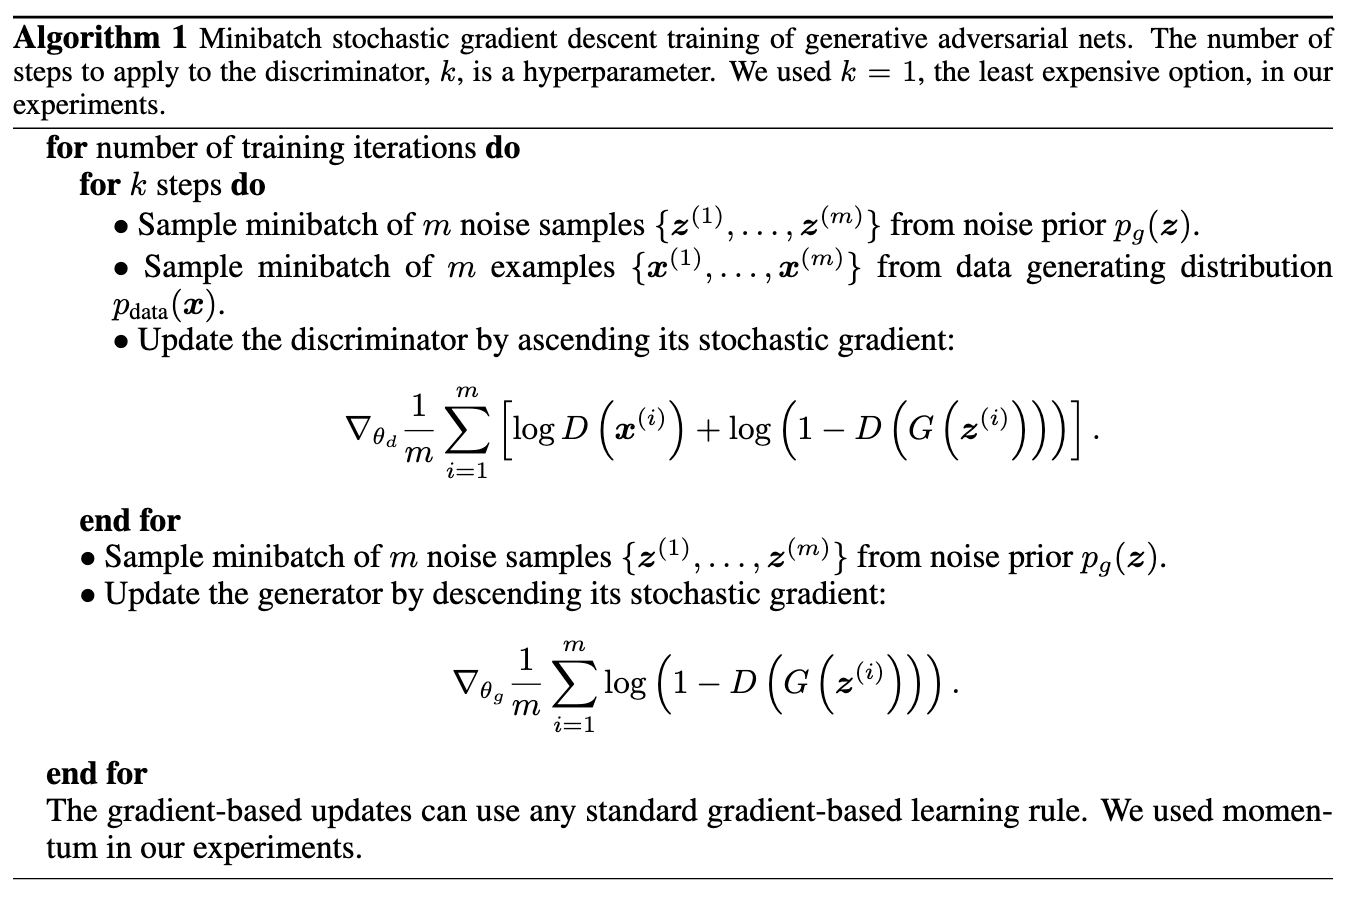

# Discriminator objection
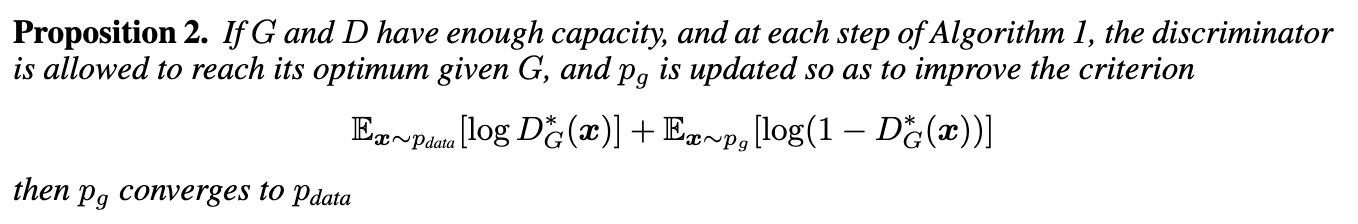

# Generator Objection (only G-relatived part)
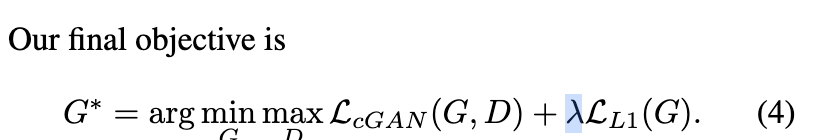

In [34]:
#training

def train():
    #dataset & dataloader
    dataset=PairedDataset(data_root=data_root,image_size=img_size)

    loader=DataLoader(dataset=dataset,batch_size=batch_size,shuffle=True,num_workers=4,pin_memory=True)

    #models
    netG=UnetGenerator().to(device=device)
    netD=NLayerDiscriminator().to(device=device)
    netG.apply(init_weights)
    netD.apply(init_weights)

    #losses: can use MSE or BCE
    loss_cGAN=nn.BCEWithLogitsLoss() #calculate the 2 parts of L_cGAN
    Loss_L1=nn.L1Loss()

    #optimizers
    optG=optim.Adam(netG.parameters(),lr=lr,betas=(beta,0.999))
    optD=optim.Adam(netD.parameters(),lr=lr,betas=(beta,0.999))

    for epoch in range(1,epoch_num+1):
        for idx,(input_img,target_img) in enumerate(loader):

            input_img=input_img.to(device)
            target_img=target_img.to(device)

            #define true label and fake label for discriminator, label shape should match the output out discriminator(feature map)

            real_label=torch.ones(size=(input_img.size(0),1,30,30),device=device)

            fake_label=torch.zeros_like(real_label,device=device)

            netD.train()
            netG.train()

     #---------update discriminator-----------------
            optD.zero_grad()
            #real
            out_real=netD(input_img,target_img)
            #align real_abel shape to the out_label
            real_label_resized=torch.ones_like(out_real,device=device)

            loss_D_real=loss_cGAN(out_real,real_label_resized)

            #fake
            fake_img=netG(input_img).detach()
            out_fake=netD(input_img,fake_img)
            fake_label_resized=torch.zeros_like(out_fake,device=device)

            loss_D_fake=loss_cGAN(out_fake,fake_label_resized)

            loss_D=(loss_D_real + loss_D_fake) *0.5

            loss_D.backward()
            optD.step()

    #-------------update generator-------------------

            optG.zero_grad()
            gen_img=netG(input_img)
            out_gen=netD(input_img,gen_img)

            loss_G_GAN=loss_cGAN(out_gen,torch.ones_like(out_gen,device=device))
            #compare out_gen with true_label because: min(G) E[log(1-D(G(x,z)))]
            loss_G_l1=Loss_L1(gen_img,target_img)*lambda_L1
            loss_G= loss_G_GAN + loss_G_l1

            loss_G.backward()
            optG.step()


            if idx %100 ==0:
                print(f'Epoch[{epoch}/{epoch_num}] Batch [{idx}/{len(loader)}]'
                      f'Loss_D:{loss_D.item():.4f}, Loss_G_GAN:{loss_G_GAN.item():.4f}, Loss_G_L1:{loss_G_l1.item():.4f}'
                 )

        #save the sample when training
        if epoch % save_frequency==0 or epoch ==1:
            netG.eval()
            with torch.no_grad():
                inp,tgt = next(iter(loader))
                inp=inp.to(device)
                tgt=tgt.to(device)

                gen=netG(inp)
                save_samples(inp.cpu(),tgt.cpu(),gen.cpu(),epoch,out_dir)
            netG.train()
            #save checkpoints
            torch.save({'epoch':epoch,
                        'netG':netG.state_dict(),
                        'netD':netD.state_dict(),
                        'optG':optG.state_dict(),
                        'optD':optD.state_dict()},
                       os.path.join(out_dir,f"checkpoint_epoch_{epoch:04d}.pth"))

    print("finished")

train()




















Epoch[1/200] Batch [0/137]Loss_D:0.8394, Loss_G_GAN:0.9340, Loss_G_L1:83.9508
Epoch[1/200] Batch [100/137]Loss_D:0.6349, Loss_G_GAN:0.9323, Loss_G_L1:80.4171
Epoch[2/200] Batch [0/137]Loss_D:0.5874, Loss_G_GAN:1.0015, Loss_G_L1:79.4481
Epoch[2/200] Batch [100/137]Loss_D:0.4333, Loss_G_GAN:1.1999, Loss_G_L1:74.7027
Epoch[3/200] Batch [0/137]Loss_D:0.4224, Loss_G_GAN:1.2699, Loss_G_L1:76.3550
Epoch[3/200] Batch [100/137]Loss_D:0.3092, Loss_G_GAN:1.5278, Loss_G_L1:72.8695
Epoch[4/200] Batch [0/137]Loss_D:0.2781, Loss_G_GAN:1.6137, Loss_G_L1:71.9653
Epoch[4/200] Batch [100/137]Loss_D:0.1842, Loss_G_GAN:1.8759, Loss_G_L1:66.2456
Epoch[5/200] Batch [0/137]Loss_D:0.1927, Loss_G_GAN:1.9614, Loss_G_L1:68.2192
Epoch[5/200] Batch [100/137]Loss_D:0.1317, Loss_G_GAN:2.1547, Loss_G_L1:62.5255
Epoch[6/200] Batch [0/137]Loss_D:0.1126, Loss_G_GAN:2.2203, Loss_G_L1:61.5466
Epoch[6/200] Batch [100/137]Loss_D:0.1311, Loss_G_GAN:2.3846, Loss_G_L1:60.7112
Epoch[7/200] Batch [0/137]Loss_D:0.1246, Loss_G_GAN:

In [35]:
!zip -r model_checkpoints.zip *
from google.colab import files
files.download("model_checkpoints.zip")

  adding: checkpoint_epoch_0001.pth (deflated 15%)
  adding: checkpoint_epoch_0005.pth (deflated 15%)
  adding: checkpoint_epoch_0010.pth (deflated 15%)
  adding: checkpoint_epoch_0015.pth (deflated 15%)
  adding: checkpoint_epoch_0020.pth (deflated 15%)
  adding: checkpoint_epoch_0025.pth (deflated 15%)
  adding: checkpoint_epoch_0030.pth (deflated 14%)
  adding: checkpoint_epoch_0035.pth (deflated 14%)
  adding: checkpoint_epoch_0040.pth (deflated 14%)
  adding: checkpoint_epoch_0045.pth (deflated 14%)
  adding: checkpoint_epoch_0050.pth (deflated 14%)
  adding: checkpoint_epoch_0055.pth (deflated 14%)
  adding: checkpoint_epoch_0060.pth (deflated 14%)
  adding: checkpoint_epoch_0065.pth (deflated 14%)
  adding: checkpoint_epoch_0070.pth (deflated 14%)
  adding: checkpoint_epoch_0075.pth (deflated 14%)
  adding: checkpoint_epoch_0080.pth (deflated 14%)
  adding: checkpoint_epoch_0085.pth (deflated 14%)
  adding: checkpoint_epoch_0090.pth (deflated 14%)
  adding: checkpoint_epoch_0095

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>